# K-Nearest Neighbors Regression
KNN Regression predicts the value of a point by averaging the values of its neighbors. This creates a non-parametric, local approximation of the function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from knn_regressor import MyKNNRegressor

## 1. Generate Synthetic 1D Data
We create a sine wave with some noise to simulate a real-world regression problem.

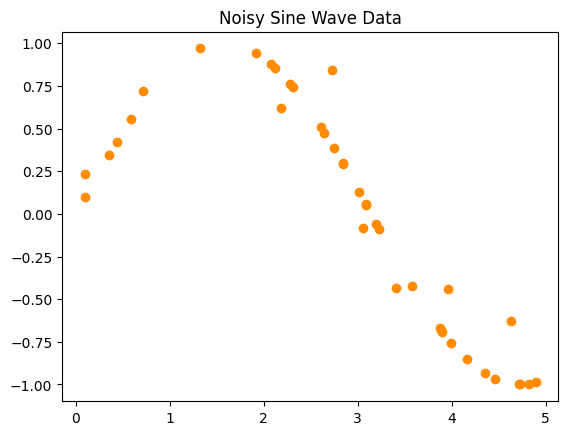

In [2]:
np.random.seed(0)
X = np.sort(5 * np.random.rand(40, 1), axis=0)
T = np.linspace(0, 5, 500)[:, np.newaxis]
y = np.sin(X).ravel()

# Add noise to targets
y[::5] += 1 * (0.5 - np.random.rand(8))

plt.scatter(X, y, color='darkorange', label='data')
plt.title("Noisy Sine Wave Data")
plt.show()

## 2. Visualize Regression Fit
We will fit the KNN Regressor with different values of K. Notice how small K results in jagged predictions (overfitting) while large K smooths out the curve too much (underfitting).

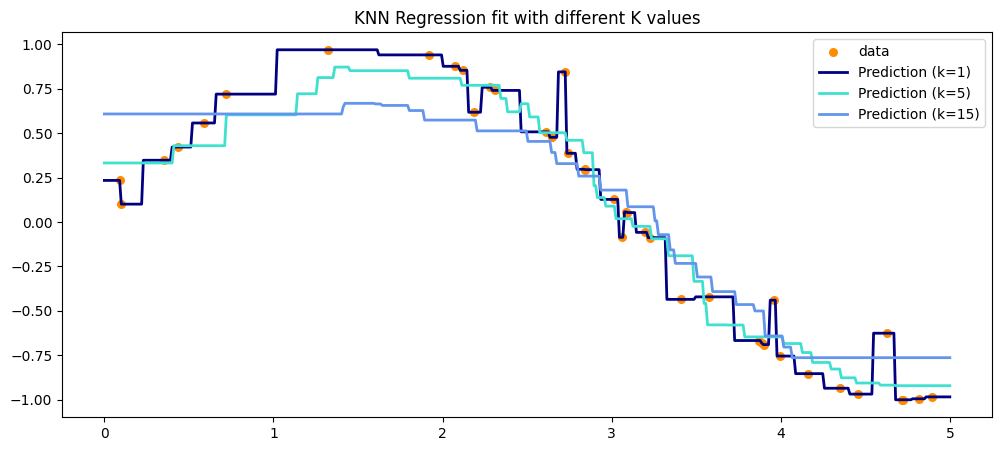

In [3]:
def plot_regression(k_values):
    plt.figure(figsize=(12, 5))
    plt.scatter(X, y, color='darkorange', label='data', s=30)
    
    colors = ['navy', 'turquoise', 'cornflowerblue']
    
    for i, k in enumerate(k_values):
        reg = MyKNNRegressor(k=k)
        reg.fit(X, y)
        y_pred = reg.predict(T)
        
        plt.plot(T, y_pred, color=colors[i], label=f'Prediction (k={k})', linewidth=2)
        
    plt.axis('tight')
    plt.legend()
    plt.title("KNN Regression fit with different K values")
    plt.show()

# Compare k=1, k=5, k=15
plot_regression([1, 5, 15])

### Interpretation
* **k=1 (Navy):** The line hits every single noisy point perfectly. This is high variance (overfitting).
* **k=5 (Turquoise):** Captures the sine wave shape well while ignoring some noise. Good balance.
* **k=15 (Cornflower):** Too smooth, almost a flat line in some places. High bias (underfitting).